# 🎯 Projet Data Science : Scoring et Segmentation Client (Intersport)
**Auteur :** AFFOUDJI Akomédi Paterne

**Date :** Février 2026

## 📌 Objectif
Analyser la base de données clients pour identifier les profils types et prédire la probabilité d'adhésion à la nouvelle carte de fidélité.

## ⚙️ Méthodologie
1. **Audit des données** : Vérification de la qualité.
2. **Sélection de variables** : Test du Chi-2 et V de Cramer.
3. **Clustering** : Segmentation K-Means.
4. **Modélisation** : Régression Logistique pour le scoring.

In [1]:
# !pip install seaborn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Configuration du style des graphiques
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


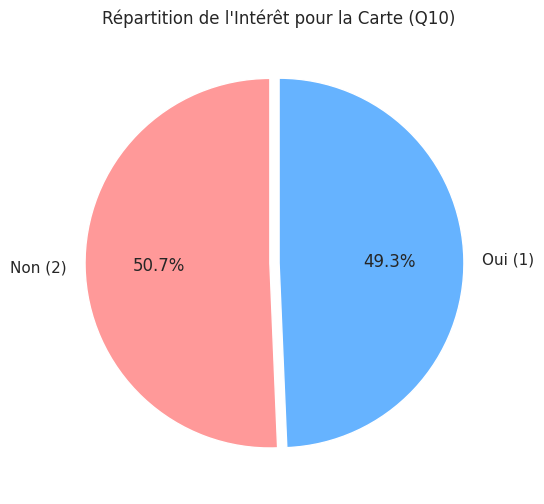

Taille de l'échantillon : 225 clients


In [3]:

file_path = '/content/donnees_isport.xls'
df = pd.read_excel(file_path)

# --- VISUALISATION DE LA CIBLE (Q10) ---
plt.figure(figsize=(6, 6))
df['Q10'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff'],
    labels=['Non (2)', 'Oui (1)'],
    startangle=90,
    explode=(0.05, 0)
)
plt.title("Répartition de l'Intérêt pour la Carte (Q10)")
plt.ylabel('')
plt.show()

print(f"Taille de l'échantillon : {df.shape[0]} clients")

In [4]:
target = 'Q10'
all_columns = [col for col in df.columns if col not in ['obs', target]]
results = []

for col in all_columns:
    table = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(table)

    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    v = np.sqrt(phi2 / min(k-1, r-1))

    results.append({'Variable': col, 'P-value': p, 'Cramer_V': v})

# Création du tableau
summary_df = pd.DataFrame(results).sort_values(by='Cramer_V', ascending=False)

print("--- Top 15 des meilleurs prédicteurs ---")
display(summary_df.head(15).style.background_gradient(cmap='Greens', subset=['Cramer_V']))

--- Top 15 des meilleurs prédicteurs ---


,Variable,P-value,Cramer_V
20,Q11,0.000000,1.000000
26,Q13,0.000000,1.000000
6,Q7,0.000000,0.539561
25,Q12e,0.000000,0.487265
2,Q3,0.000000,0.475228
54,Q23,0.000000,0.459849
27,Q14,0.000000,0.453375
5,Q6,0.000000,0.439620
3,Q4,0.000000,0.413176
31,Q18,0.000000,0.406185


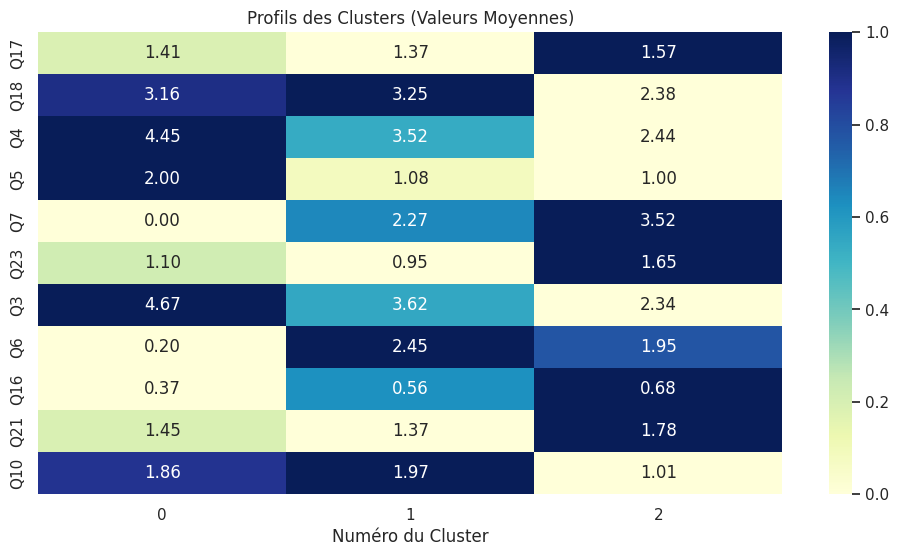

Taille des groupes :
Cluster
2    103
1     73
0     49
Name: count, dtype: int64


In [5]:
features_clustering = ['Q17', 'Q18', 'Q4', 'Q5', 'Q7', 'Q23', 'Q3', 'Q6', 'Q16', 'Q21']
data_for_clustering = df[features_clustering + ['Q10']]

# Standardisation
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_clustering)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(data_scaled)

# --- VISUALISATION DES PROFILS (HEATMAP) ---
# On calcule la moyenne de chaque variable par groupe
cluster_means = df.groupby('Cluster')[features_clustering + ['Q10']].mean()

# On normalise juste pour l'affichage (pour que les couleurs soient comparables)
cluster_means_normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means_normalized.T, annot=cluster_means.T, fmt=".2f", cmap="YlGnBu")
plt.title("Profils des Clusters (Valeurs Moyennes)")
plt.xlabel("Numéro du Cluster")
plt.show()

print("Taille des groupes :")
print(df['Cluster'].value_counts())

Optimization terminated successfully.
         Current function value: 0.337255
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  225
Model:                          Logit   Df Residuals:                      217
Method:                           MLE   Df Model:                            7
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                  0.5134
Time:                        06:20:17   Log-Likelihood:                -75.882
converged:                       True   LL-Null:                       -155.94
Covariance Type:            nonrobust   LLR p-value:                 3.039e-31
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8771      1.042     -0.842      0.400      -2.919       1.165
Q17            1.0143      0.

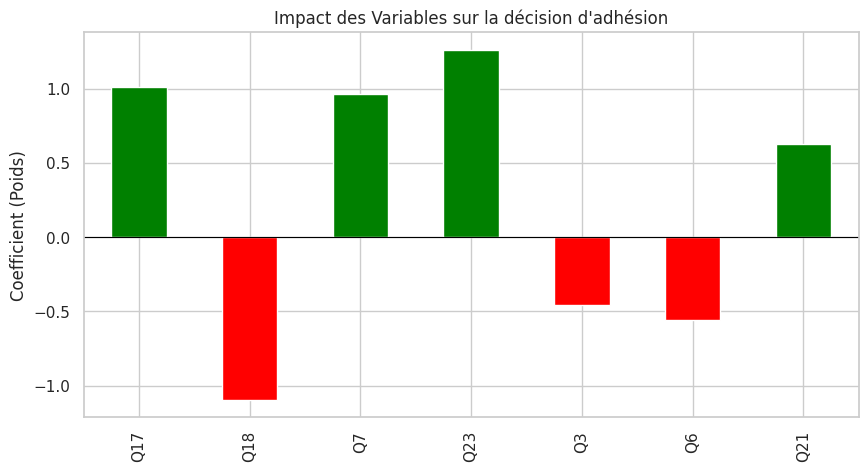

In [6]:
# Préparation
df['target'] = df['Q10'].map({1: 1, 2: 0})
final_features = ['Q17', 'Q18', 'Q7', 'Q23', 'Q3', 'Q6', 'Q21']

X = df[final_features]
X = sm.add_constant(X)
y = df['target']

# Modèle
final_logit = sm.Logit(y, X).fit()

# Affichage du résumé statistique
print(final_logit.summary())

# --- VISUALISATION DES COEFFICIENTS (POIDS) ---
coeffs = final_logit.params.drop('const') # On enlève la constante pour le graphe
colors = ['red' if c < 0 else 'green' for c in coeffs]

plt.figure(figsize=(10, 5))
coeffs.plot(kind='bar', color=colors)
plt.title("Impact des Variables sur la décision d'adhésion")
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Coefficient (Poids)")
plt.show()

In [ ]:
# Calcul du Score
df['Probabilite_Adhesion'] = final_logit.predict(X)
df['Prediction_Interet'] = (df['Probabilite_Adhesion'] > 0.5).astype(int)

# Vérification de la performance (Matrice de Confusion visuelle)
confusion = pd.crosstab(df['target'], df['Prediction_Interet'], rownames=['Réel'], colnames=['Prédit'])

plt.figure(figsize=(5, 4))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matrice de Confusion (Performance)")
plt.show()

# Export
export_columns = ['Q10'] + final_features + ['Probabilite_Adhesion', 'Prediction_Interet', 'Cluster']
filename = 'Resultats_Scoring_Intersport.csv'
df[export_columns].to_csv(filename, index=False)

print(f"✅ Fichier '{filename}' généré avec succès !")
display(df[export_columns].head())